Dataset shape: (442, 11)
Columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'target']
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  

Missing values before cleaning:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Missing va

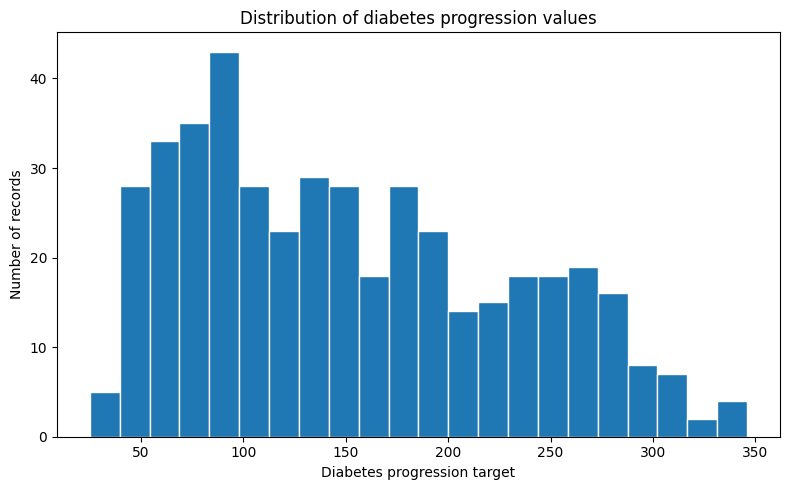

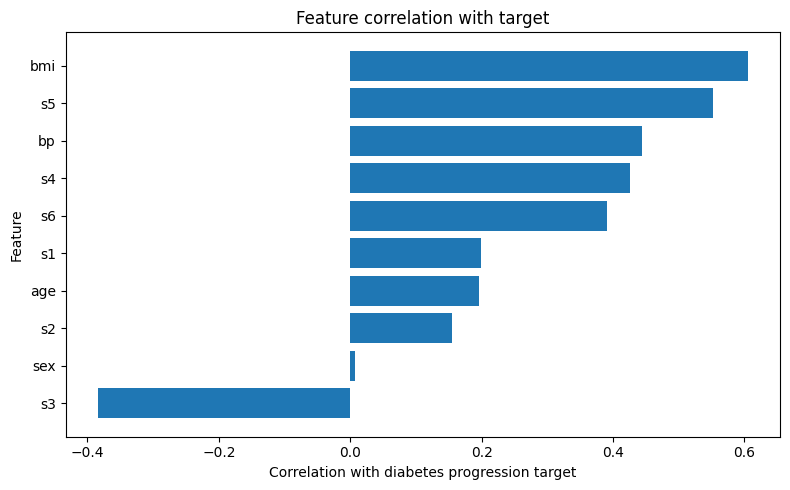

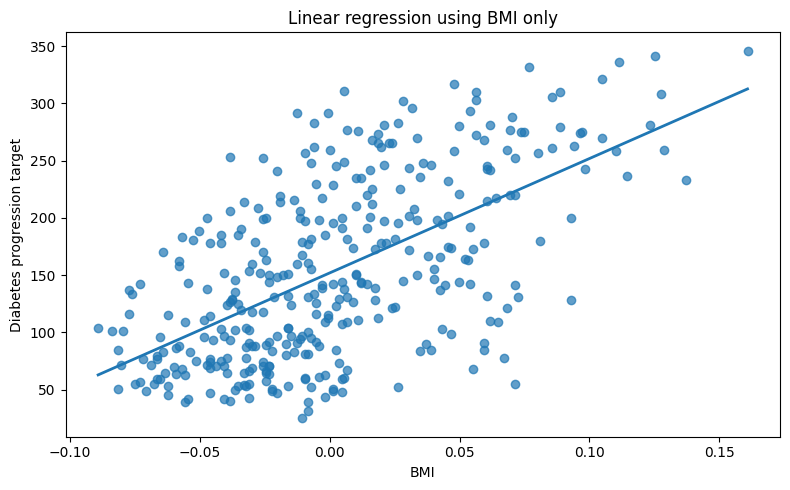

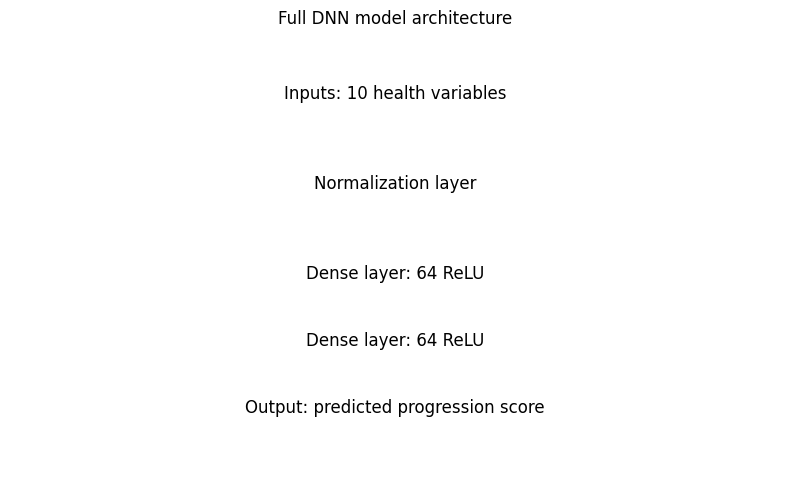


Model results:
                           Model        MAE       RMSE        R2
0    Linear Regression: BMI only  52.259976  63.732456  0.233350
1  Linear Regression: all inputs  42.794095  53.853446  0.452603
2       DNN Regression: BMI only  51.947943  65.969087  0.178596
3     DNN Regression: full model  43.457226  54.121988  0.447130

Sample predictions:
   Actual   Predicted       Error
0   219.0  139.782654  -79.217346
1    70.0  193.746597  123.746597
2   202.0  136.888901  -65.111099
3   230.0  314.182343   84.182343
4   111.0   73.285088  -37.714912
5    84.0  100.211548   16.211548
6   242.0  289.655029   47.655029
7   272.0  177.496017  -94.503983
8    94.0   98.253067    4.253067
9    96.0   81.560371  -14.439629


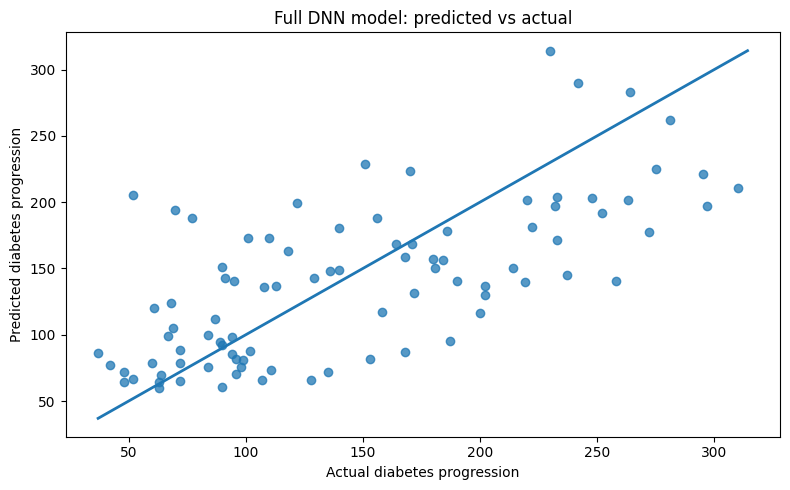

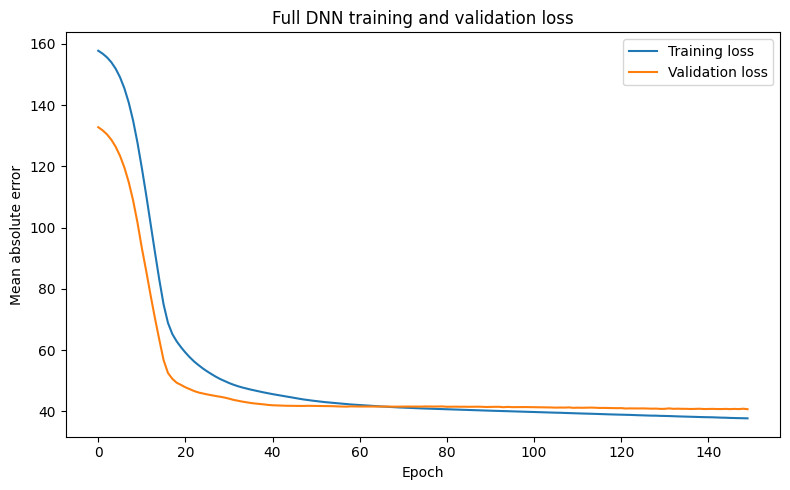

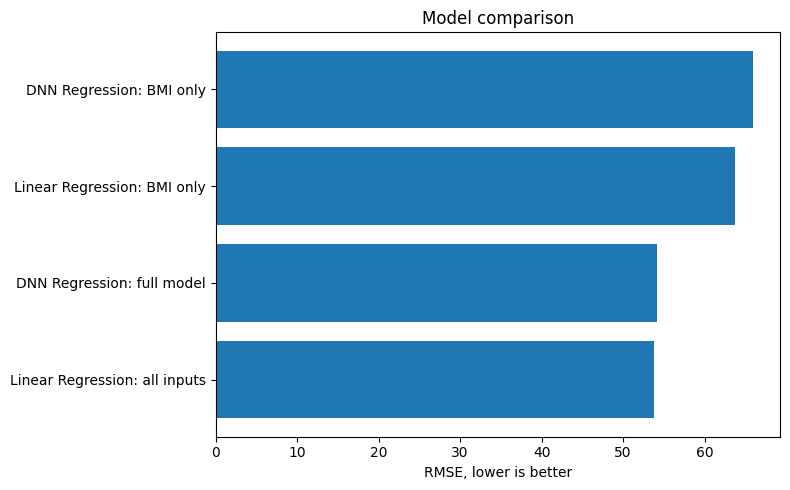


Reloaded model test prediction:
[[139.78267]]

Files created:
target_distribution.png
feature_correlation.png
bmi_linear.png
model_architecture.png
project8_predicted_vs_actual.png
project8_dnn_loss_curve.png
project8_model_comparison.png
project8_model_metrics.csv
project8_predictions.csv
project8_diabetes_dnn_model.keras


In [1]:
import os
os.environ["PYTHONHASHSEED"] = "42"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

diabetes = load_diabetes(as_frame=True)
df = diabetes.frame.copy()

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print(df.head())

print("\nMissing values before cleaning:")
print(df.isna().sum())

df = df.dropna()

print("\nMissing values after cleaning:")
print(df.isna().sum())

train_dataset, test_dataset = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED
)

print("\nTraining data shape:", train_dataset.shape)
print("Testing data shape:", test_dataset.shape)

print("\nSummary statistics:")
print(train_dataset.describe())

print("\nCorrelation with target:")
print(train_dataset.corr(numeric_only=True)["target"].sort_values(ascending=False))

plt.figure(figsize=(8, 5))
plt.hist(df["target"], bins=22, edgecolor="white")
plt.xlabel("Diabetes progression target")
plt.ylabel("Number of records")
plt.title("Distribution of diabetes progression values")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=200)
plt.show()

correlations = train_dataset.corr(numeric_only=True)["target"].drop("target").sort_values()

plt.figure(figsize=(8, 5))
plt.barh(correlations.index, correlations.values)
plt.xlabel("Correlation with diabetes progression target")
plt.ylabel("Feature")
plt.title("Feature correlation with target")
plt.tight_layout()
plt.savefig("feature_correlation.png", dpi=200)
plt.show()

train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop("target")
test_labels = test_features.pop("target")

one_feature = "bmi"
train_bmi = train_features[[one_feature]]
test_bmi = test_features[[one_feature]]

bmi_normalizer = tf.keras.layers.Normalization(axis=-1)
bmi_normalizer.adapt(np.array(train_bmi, dtype=np.float32))

full_normalizer = tf.keras.layers.Normalization(axis=-1)
full_normalizer.adapt(np.array(train_features, dtype=np.float32))

def compile_and_fit(model, train_x, train_y, epochs=150, learning_rate=0.001):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mean_absolute_error"
    )

    history = model.fit(
        np.array(train_x, dtype=np.float32),
        np.array(train_y, dtype=np.float32),
        validation_split=0.20,
        epochs=epochs,
        verbose=0
    )

    return history

def evaluate_model(model_name, model, test_x, test_y):
    if isinstance(model, tf.keras.Model):
        predictions = model.predict(
            np.array(test_x, dtype=np.float32),
            verbose=0
        ).flatten()
    else:
        predictions = model.predict(test_x).flatten()

    mae = mean_absolute_error(test_y, predictions)
    rmse = mean_squared_error(test_y, predictions) ** 0.5
    r2 = r2_score(test_y, predictions)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Predictions": predictions
    }


linear_bmi_model = LinearRegression()
linear_bmi_model.fit(train_bmi, train_labels)

linear_full_model = LinearRegression()
linear_full_model.fit(train_features, train_labels)

# BMI only
bmi_line_x = np.linspace(
    train_bmi["bmi"].min(),
    train_bmi["bmi"].max(),
    100
).reshape(-1, 1)

bmi_line_y = linear_bmi_model.predict(pd.DataFrame(bmi_line_x, columns=["bmi"]))

plt.figure(figsize=(8, 5))
plt.scatter(train_bmi["bmi"], train_labels, alpha=0.70)
plt.plot(bmi_line_x, bmi_line_y, linewidth=2)
plt.xlabel("BMI")
plt.ylabel("Diabetes progression target")
plt.title("Linear regression using BMI only")
plt.tight_layout()
plt.savefig("bmi_linear.png", dpi=200)
plt.show()


dnn_bmi_model = tf.keras.Sequential([
    bmi_normalizer,
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])

history_dnn_bmi = compile_and_fit(
    dnn_bmi_model,
    train_bmi,
    train_labels,
    epochs=150,
    learning_rate=0.001
)

dnn_full_model = tf.keras.Sequential([
    full_normalizer,
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1)
])

history_dnn_full = compile_and_fit(
    dnn_full_model,
    train_features,
    train_labels,
    epochs=150,
    learning_rate=0.001
)

plt.figure(figsize=(8, 5))
plt.text(0.5, 0.85, "Inputs: 10 health variables", ha="center", fontsize=12)
plt.text(0.5, 0.65, "Normalization layer", ha="center", fontsize=12)
plt.text(0.5, 0.45, "Dense layer: 64 ReLU", ha="center", fontsize=12)
plt.text(0.5, 0.30, "Dense layer: 64 ReLU", ha="center", fontsize=12)
plt.text(0.5, 0.15, "Output: predicted progression score", ha="center", fontsize=12)
plt.axis("off")
plt.title("Full DNN model architecture")
plt.tight_layout()
plt.savefig("model_architecture.png", dpi=200)
plt.show()


results = []
results.append(evaluate_model("Linear Regression: BMI only", linear_bmi_model, test_bmi, test_labels))
results.append(evaluate_model("Linear Regression: all inputs", linear_full_model, test_features, test_labels))
results.append(evaluate_model("DNN Regression: BMI only", dnn_bmi_model, test_bmi, test_labels))
results.append(evaluate_model("DNN Regression: full model", dnn_full_model, test_features, test_labels))

metrics_table = pd.DataFrame([
    {
        "Model": r["Model"],
        "MAE": r["MAE"],
        "RMSE": r["RMSE"],
        "R2": r["R2"]
    }
    for r in results
])

print("\nModel results:")
print(metrics_table)

metrics_table.to_csv("project8_model_metrics.csv", index=False)

# Predictions
full_dnn_predictions = results[-1]["Predictions"]

prediction_table = pd.DataFrame({
    "Actual": test_labels.values,
    "Predicted": full_dnn_predictions,
    "Error": full_dnn_predictions - test_labels.values
})

print("\nSample predictions:")
print(prediction_table.head(10))

prediction_table.to_csv("project8_predictions.csv", index=False)

# Predicted vs
plt.figure(figsize=(8, 5))
plt.scatter(test_labels, full_dnn_predictions, alpha=0.75)

line_min = min(test_labels.min(), full_dnn_predictions.min())
line_max = max(test_labels.max(), full_dnn_predictions.max())

plt.plot([line_min, line_max], [line_min, line_max], linewidth=2)
plt.xlabel("Actual diabetes progression")
plt.ylabel("Predicted diabetes progression")
plt.title("Full DNN model: predicted vs actual")
plt.tight_layout()
plt.savefig("project8_predicted_vs_actual.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_dnn_full.history["loss"], label="Training loss")
plt.plot(history_dnn_full.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Mean absolute error")
plt.title("Full DNN training and validation loss")
plt.legend()
plt.tight_layout()
plt.savefig("project8_dnn_loss_curve.png", dpi=200)
plt.show()

metrics_sorted = metrics_table.sort_values("RMSE", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(metrics_sorted["Model"], metrics_sorted["RMSE"])
plt.xlabel("RMSE, lower is better")
plt.title("Model comparison")
plt.tight_layout()
plt.savefig("project8_model_comparison.png", dpi=200)
plt.show()

dnn_full_model.save("project8_diabetes_dnn_model.keras")

reloaded_model = tf.keras.models.load_model("project8_diabetes_dnn_model.keras")

print("\nReloaded model test prediction:")
print(reloaded_model.predict(np.array(test_features.head(1), dtype=np.float32), verbose=0))

print("\nFiles created:")
print("target_distribution.png")
print("feature_correlation.png")
print("bmi_linear.png")
print("model_architecture.png")
print("project8_predicted_vs_actual.png")
print("project8_dnn_loss_curve.png")
print("project8_model_comparison.png")
print("project8_model_metrics.csv")
print("project8_predictions.csv")
print("project8_diabetes_dnn_model.keras")